In [1]:
import pandas as pd

df = pd.read_csv(
    "/content/sample_data/patient_level_dataset.csv"
)

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(10, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient Name     10 non-null     object 
 1   AS7341_415nm     10 non-null     float64
 2   AS7341_445nm     10 non-null     float64
 3   AS7341_480nm     10 non-null     float64
 4   AS7341_515nm     10 non-null     float64
 5   AS7341_555nm     10 non-null     float64
 6   AS7341_590nm     10 non-null     float64
 7   AS7341_630nm     10 non-null     float64
 8   AS7341_680nm     10 non-null     float64
 9   MAX30102_RED     10 non-null     float64
 10  MAX30102_IR      10 non-null     float64
 11  Actual_Hgb       10 non-null     float64
 12  Actual_RBC       10 non-null     float64
 13  RED_IR_RATIO     10 non-null     float64
 14  RED_IR_DIFF      10 non-null     float64
 15  R630_R680_RATIO  10 non-null     float64
 16  R630_R680_DIFF   10 non-null     float64
 17  R590_R680_

In [2]:
corr_matrix = df.drop(
    columns=["Patient Name"]
).corr()

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
hgb_corr = (
    corr_matrix["Actual_Hgb"]
    .sort_values(ascending=False)
)

In [5]:
print(hgb_corr)

Actual_Hgb         1.000000
Actual_RBC         0.366902
RED_IR_DIFF        0.364849
RED_IR_RATIO       0.215031
R630_R680_RATIO   -0.113341
R555_R680_RATIO   -0.146687
R590_R680_RATIO   -0.213637
R680_IR_RATIO     -0.221323
AS7341_480nm      -0.236149
AS7341_515nm      -0.238137
AS7341_445nm      -0.273512
R630_RED_RATIO    -0.281797
R630_R680_DIFF    -0.293692
AS7341_415nm      -0.315447
AS7341_630nm      -0.319495
AS7341_680nm      -0.326333
AS7341_555nm      -0.354014
AS7341_590nm      -0.366818
MAX30102_RED      -0.411059
MAX30102_IR       -0.501276
Name: Actual_Hgb, dtype: float64


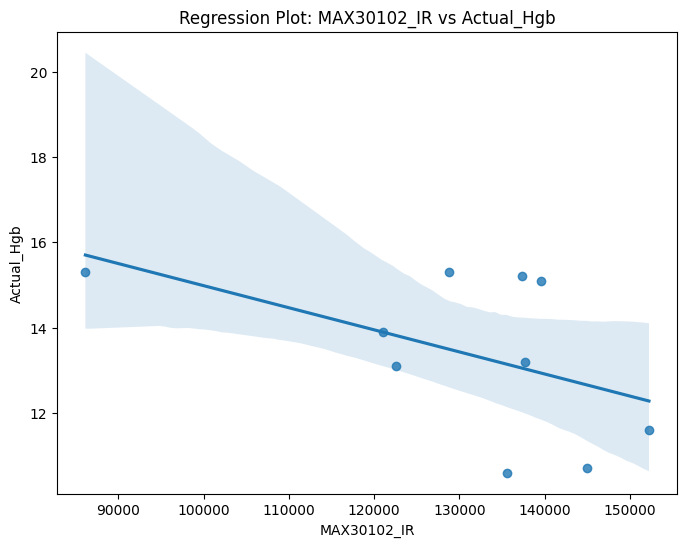

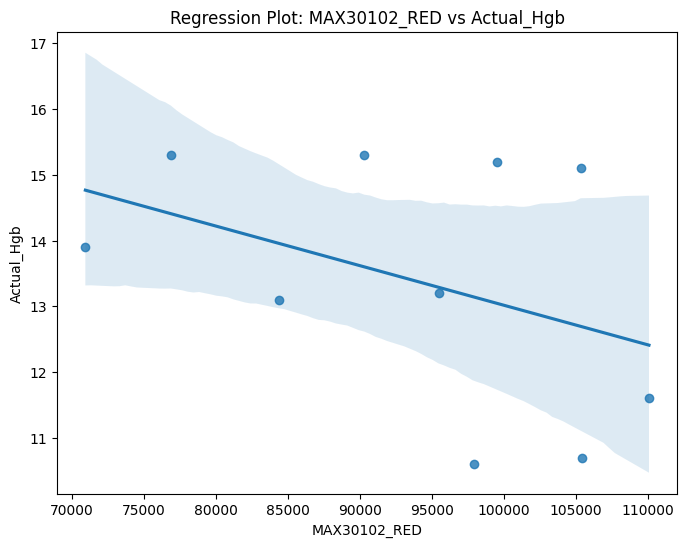

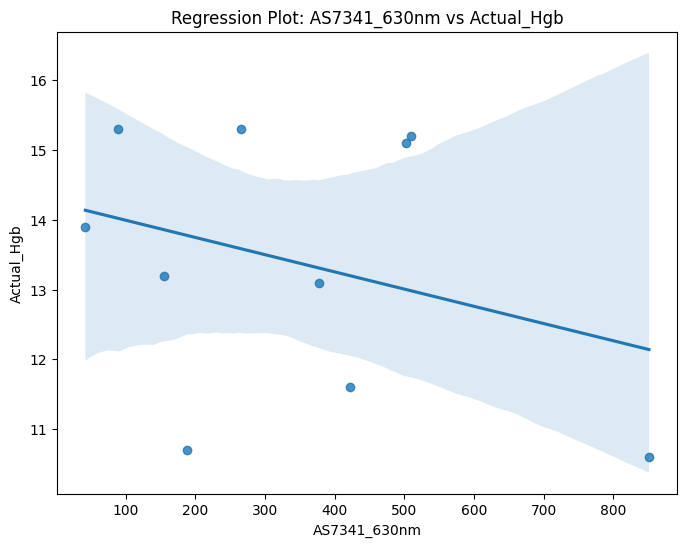

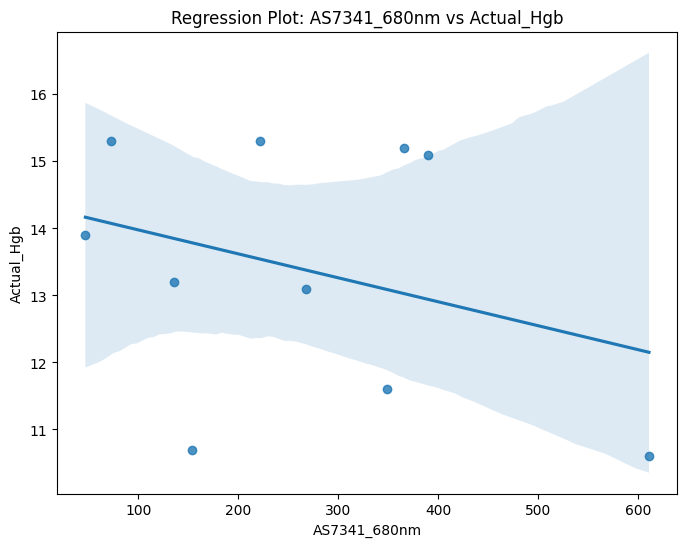

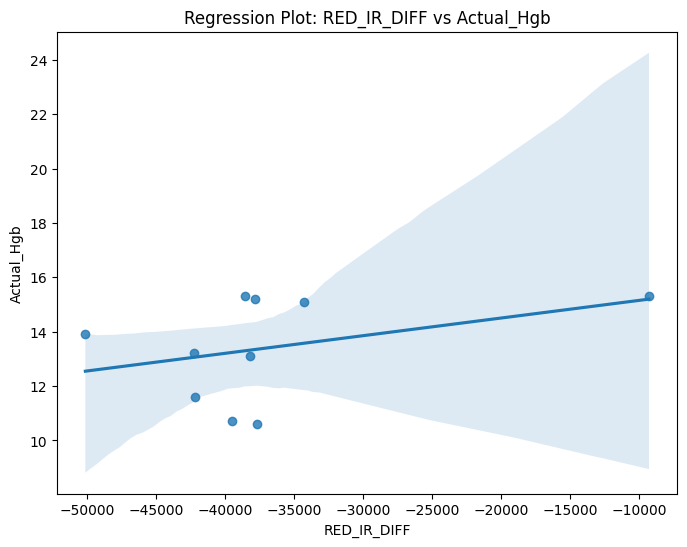

In [9]:
features = [
    "MAX30102_IR",
    "MAX30102_RED",
    "AS7341_630nm",
    "AS7341_680nm",
    "RED_IR_DIFF"
]

for feature in features:
    plt.figure(figsize=(8, 6))
    sns.regplot(
        x=df[feature],
        y=df["Actual_Hgb"]
    )
    plt.title(f'Regression Plot: {feature} vs Actual_Hgb')
    plt.xlabel(feature)
    plt.ylabel('Actual_Hgb')
    plt.show()

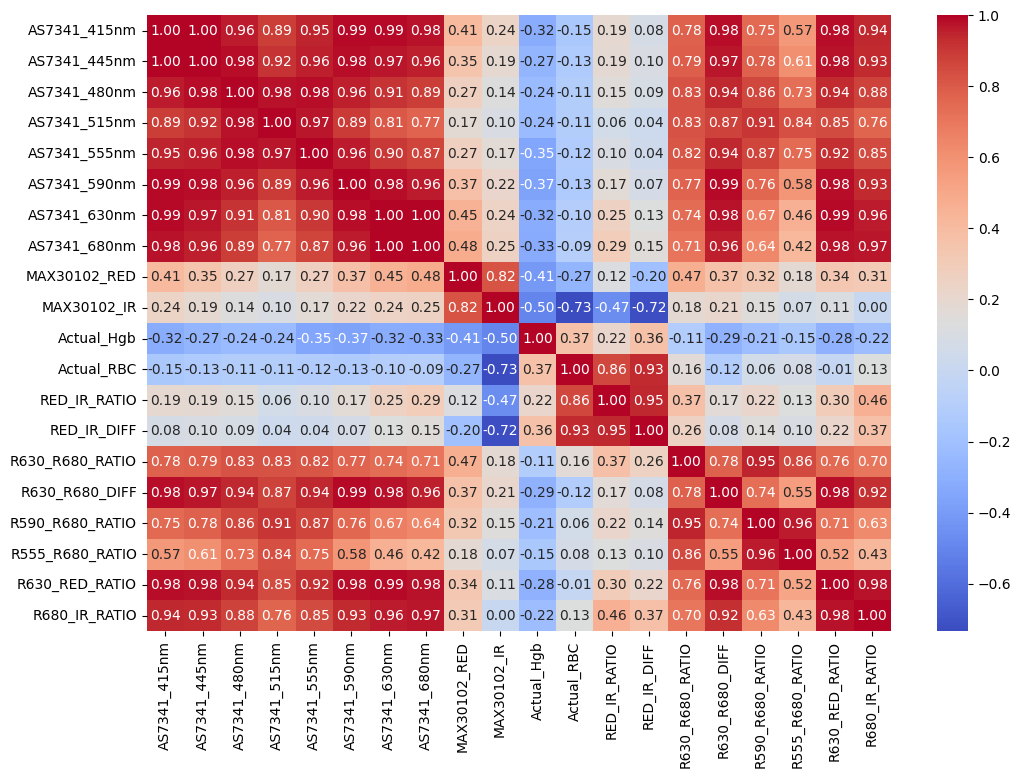

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()